In [20]:
import urllib.request, zipfile, os

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH = "/content/HAR.zip"
EXTRACT_TO = "/content/HAR_data"

print("Downloading...")
urllib.request.urlretrieve(URL, ZIP_PATH)
print(f"Done. Size: {os.path.getsize(ZIP_PATH)/1e6:.1f} MB")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)
    print(" Extracted successfully!")

Downloading...
Done. Size: 61.0 MB
 Extracted successfully!


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense,
    Dropout, BatchNormalization, TimeDistributed, Flatten
)
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [22]:
EXTRACT_TO = "/content/HAR_data"

dataset_root = None
for root, dirs, files in os.walk(EXTRACT_TO):
    if "__MACOSX" in root:
        continue
    if "train" in dirs and "test" in dirs:
        dataset_root = root
        break

assert dataset_root, "Could not find train/test folders."
print("Dataset root:", dataset_root)

print("\nFolders found:")
for item in sorted(os.listdir(dataset_root)):
    print(" ", item)

TRAIN_PATH = os.path.join(dataset_root, "train", "Inertial Signals")
TEST_PATH  = os.path.join(dataset_root, "test",  "Inertial Signals")

print("\nTrain signals folder:", TRAIN_PATH)
print("Files:", sorted(os.listdir(TRAIN_PATH))[:5], "...")


Dataset root: /content/HAR_data/UCI HAR Dataset

Folders found:
  .DS_Store
  README.txt
  activity_labels.txt
  features.txt
  features_info.txt
  test
  train

Train signals folder: /content/HAR_data/UCI HAR Dataset/train/Inertial Signals
Files: ['body_acc_x_train.txt', 'body_acc_y_train.txt', 'body_acc_z_train.txt', 'body_gyro_x_train.txt', 'body_gyro_y_train.txt'] ...


In [23]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x","body_gyro_y","body_gyro_z",
    "total_acc_x","total_acc_y","total_acc_z",
]

def load_signals(path):

    signals = []
    for sig in SIGNALS:
        candidates = [
            f for f in os.listdir(path)
            if f.startswith(sig) and not f.startswith("._")
        ]
        assert candidates, f"Signal file not found: {sig} in {path}"
        file_path = os.path.join(path, candidates[0])
        data = pd.read_csv(file_path, delim_whitespace=True, header=None).values
        signals.append(data)
    return np.transpose(np.array(signals), (1, 2, 0))

def load_labels(path):
    candidates = [
        f for f in os.listdir(path)
        if f.startswith("y_") and not f.startswith("._")
    ]
    assert candidates, f"Label file not found in {path}"
    labels = pd.read_csv(
        os.path.join(path, candidates[0]),
        header=None
    ).values.flatten()
    return labels - 1

X_train     = load_signals(TRAIN_PATH)
y_train_raw = load_labels(os.path.join(dataset_root, "train"))

X_test      = load_signals(TEST_PATH)
y_test_raw  = load_labels(os.path.join(dataset_root, "test"))

ACTIVITY_LABELS = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]
N_CLASSES = len(ACTIVITY_LABELS)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {N_CLASSES}")


/tmp/ipykernel_27280/1038916218.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None).values
/tmp/ipykernel_27280/1038916218.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None).values
/tmp/ipykernel_27280/1038916218.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None).values
/tmp/ipykernel_27280/1038916218.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=Tr

X_train : (7352, 128, 9)
X_test  : (2947, 128, 9)
Classes : 6


In [24]:
y_train = to_categorical(y_train_raw, N_CLASSES)
y_test  = to_categorical(y_test_raw,  N_CLASSES)


In [25]:
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1),  keepdims=True)

X_train = (X_train - mean) / (std + 1e-8)
X_test  = (X_test  - mean) / (std + 1e-8)

print("Normalization done. Range:", X_train.min().round(3), "→", X_train.max().round(3))

Normalization done. Range: -15.643 → 15.05


In [26]:
N_STEPS    = 4
N_LENGTH   = 32
N_FEATURES = 9

X_train_cnn = X_train.reshape(-1, N_STEPS, N_LENGTH, N_FEATURES)
X_test_cnn  = X_test.reshape( -1, N_STEPS, N_LENGTH, N_FEATURES)

print("X_train_cnn shape:", X_train_cnn.shape)

X_train_cnn shape: (7352, 4, 32, 9)


In [27]:
model = Sequential([
    TimeDistributed(Conv1D(64, 3, activation='relu', padding='same'),
                    input_shape=(N_STEPS, N_LENGTH, N_FEATURES)),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(Conv1D(64, 3, activation='relu', padding='same')),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling1D(pool_size=2)),
    TimeDistributed(Dropout(0.3)),
    TimeDistributed(Flatten()),

    LSTM(128, return_sequences=False),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(N_CLASSES, activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_7              │ (None, 4, 32, 64)      │         1,792 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 4, 32, 64)      │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 4, 32, 64)      │        12,352 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 4, 32, 64)      │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 4, 16, 64)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 4, 16, 64)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 4, 1024)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613,638 (2.34 MB)

 Trainable params: 613,382 (2.34 MB)

 Non-trainable params: 256 (1.00 KB)

In [28]:
BATCH_SIZE = 64
EPOCHS     = 30

history = model.fit(
    X_train_cnn, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8215 - loss: 0.4745 - val_accuracy: 0.9253 - val_loss: 0.1912
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9426 - loss: 0.1650 - val_accuracy: 0.9334 - val_loss: 0.1322
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9506 - loss: 0.1297 - val_accuracy: 0.9144 - val_loss: 0.1288
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9559 - loss: 0.1168 - val_accuracy: 0.9280 - val_loss: 0.1311
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9515 - loss: 0.1285 - val_accuracy: 0.9239 - val_loss: 0.1329
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9574 - loss: 0.1081 - val_accuracy: 0.9253 - val_loss: 0.1489
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9593 - loss: 0.1049 - val_accuracy: 0.9171 - val_loss: 0.2055
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9554 - loss: 0.1088 - val_accu

In [29]:
loss, acc = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Accuracy : {acc*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")



Test Accuracy : 91.55%
Test Loss     : 0.5695


In [30]:
y_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)

print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred, target_names=ACTIVITY_LABELS))



Classification Report:
                    precision    recall  f1-score   support

           WALKING       1.00      0.96      0.98       496
  WALKING_UPSTAIRS       0.90      0.94      0.92       471
WALKING_DOWNSTAIRS       0.91      1.00      0.95       420
           SITTING       0.80      0.85      0.82       491
          STANDING       0.90      0.81      0.85       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



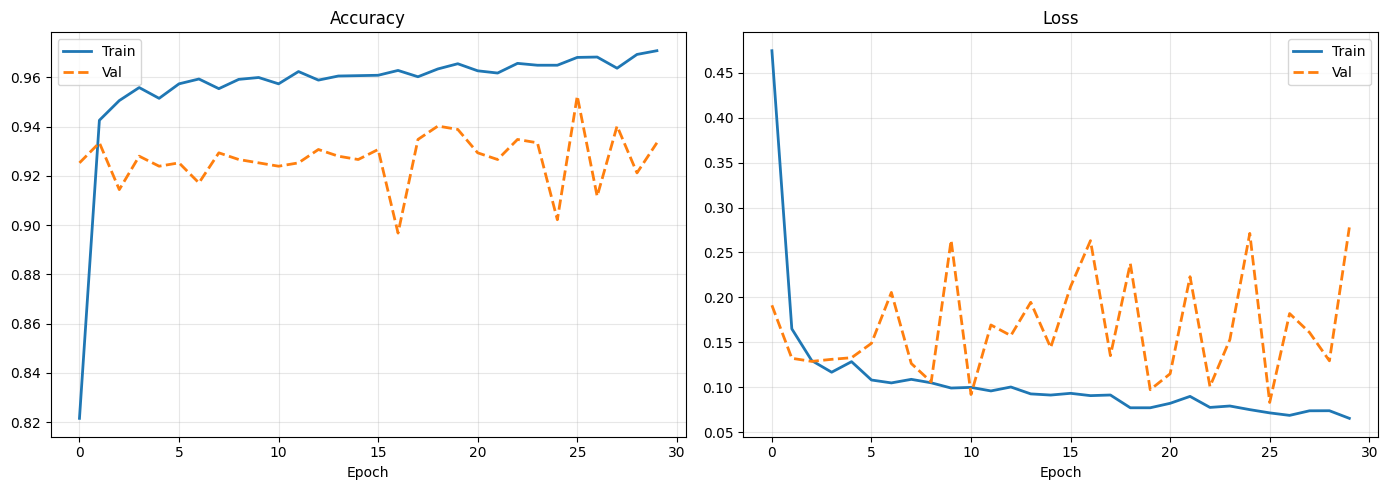

Saved: /content/training_curves.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150)
plt.show()
print("Saved: /content/training_curves.png")


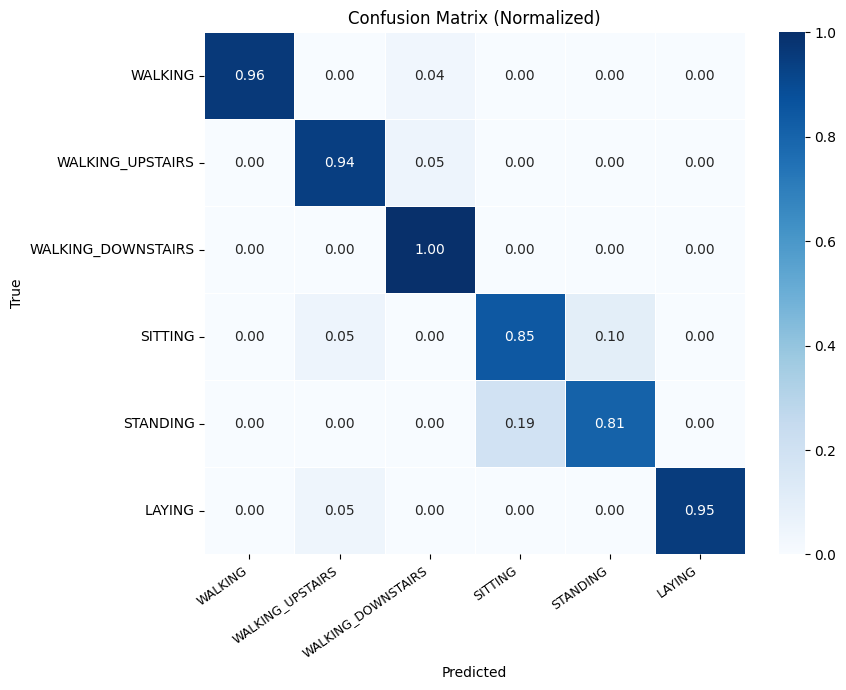

Saved: /content/confusion_matrix.png


In [32]:
cm_norm = confusion_matrix(y_test_raw, y_pred, normalize='true')

plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=ACTIVITY_LABELS, yticklabels=ACTIVITY_LABELS,
            cmap='Blues', linewidths=0.4)
plt.title('Confusion Matrix (Normalized)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()
print("Saved: /content/confusion_matrix.png")

In [33]:
model.save("/content/cnn_lstm_har_model.h5")
print("Model saved → /content/cnn_lstm_har_model.h5")


Model saved → /content/cnn_lstm_har_model.h5


In [34]:
sample_idx = 88
pred_probs = model.predict(X_test_cnn[sample_idx:sample_idx+1], verbose=0)[0]
pred_label = ACTIVITY_LABELS[np.argmax(pred_probs)]
true_label = ACTIVITY_LABELS[y_test_raw[sample_idx]]

print(f"\nSample #{sample_idx}")
print(f"  True : {true_label}")
print(f"  Pred : {pred_label}  ({'✓ Correct' if true_label == pred_label else '✗ Wrong'})")
print("\nProbabilities:")
for label, prob in zip(ACTIVITY_LABELS, pred_probs):
    print(f"  {label:<25} {prob:.3f}  {'█' * int(prob*30)}")


Sample #88
  True : WALKING
  Pred : WALKING  (✓ Correct)

Probabilities:
  WALKING                   1.000  █████████████████████████████
  WALKING_UPSTAIRS          0.000  
  WALKING_DOWNSTAIRS        0.000  
  SITTING                   0.000  
  STANDING                  0.000  
  LAYING                    0.000  


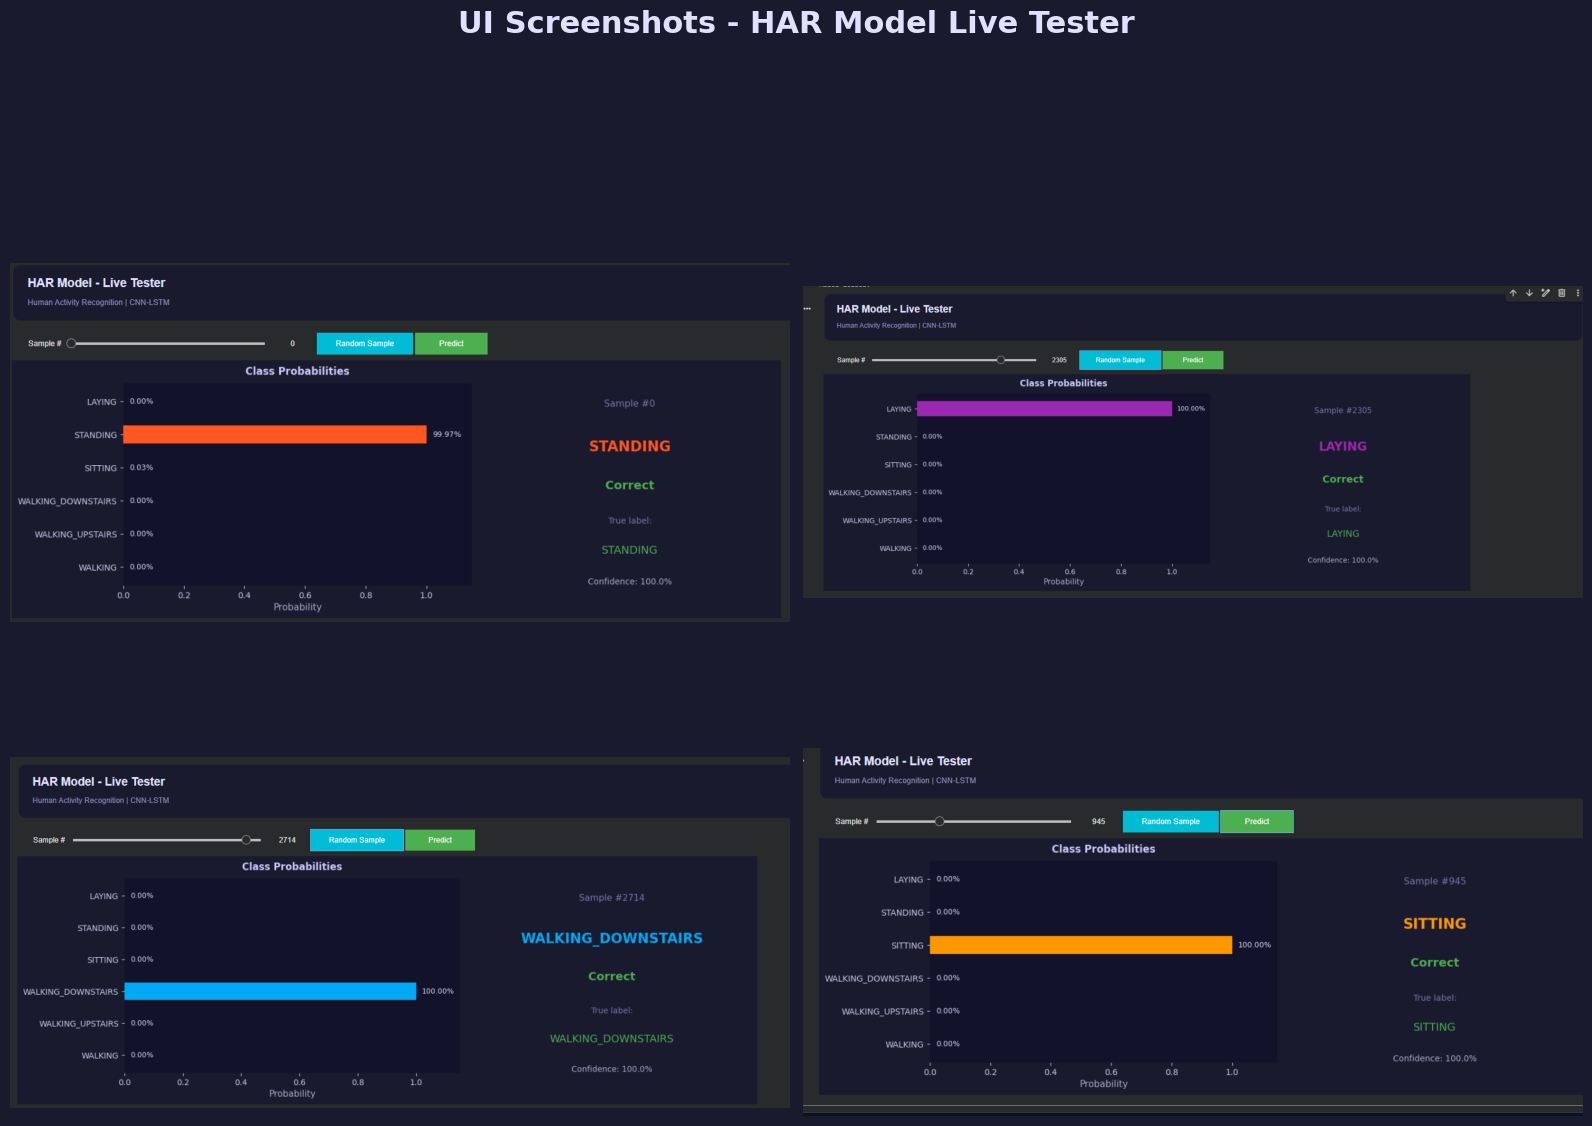

In [40]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

paths = [
    "/content/Screenshot 2026-04-04 020100.png",
    "/content/Screenshot 2026-04-04 020108.png",
    "/content/Screenshot 2026-04-04 020122.png",
    "/content/Screenshot 2026-04-04 020159.png",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("UI Screenshots - HAR Model Live Tester",
             color="#e0e0ff", fontsize=22, fontweight="bold", y=0.98)

for ax, path in zip(axes.flatten(), paths):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout(pad=1, rect=[0, 0, 1, 0.95])
plt.savefig("/content/showcase.png", dpi=150, bbox_inches="tight")
plt.show()